In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Portofolio/Superstore/data/Sample - Superstore (1).csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/08/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06/12/2016,06/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

df["Profit Margin"] = df["Profit"]/df["Sales"]

df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df[["Sales", "Profit"]].describe()

,Sales,Profit
count,9994.000000,9994.000000
mean,229.858001,28.656896
std,623.245101,234.260108
min,0.444000,-6599.978000
25%,17.280000,1.728750
50%,54.490000,8.666500
75%,209.940000,29.364000
max,22638.480000,8399.976000


In [ ]:
yearly = df.groupby("Year")[["Sales", "Profit"]].sum().reset_index()
yearly

,Year,Sales,Profit
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037
2,2016,609205.5980,81795.1743
3,2017,733215.2552,93439.2696


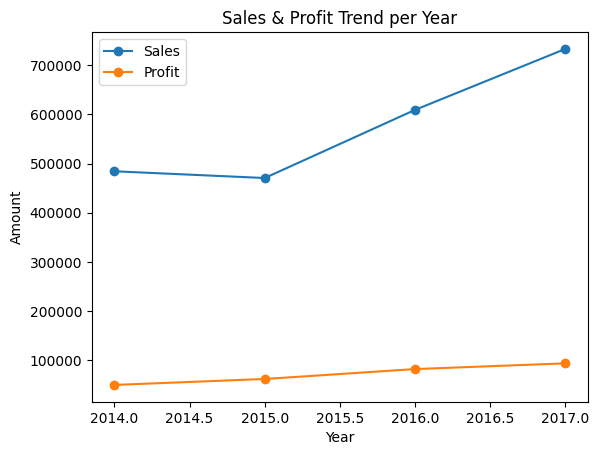

In [ ]:
plt.plot(yearly["Year"], yearly["Sales"], marker="o", label="Sales")
plt.plot(yearly["Year"], yearly["Profit"], marker="o", label="Profit")
plt.title("Sales & Profit Trend per Year")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.show()

In [ ]:
category = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)
category

,Sales,Profit
Category,,
Technology,836154.0330,145454.9481
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008


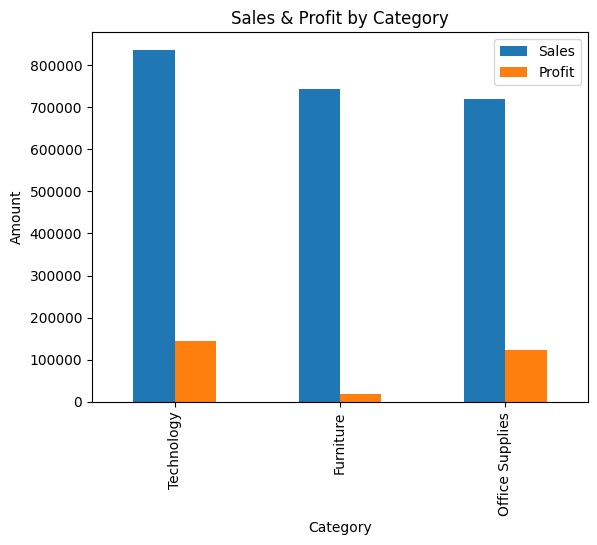

In [ ]:
category.plot(kind="bar")
plt.title("Sales & Profit by Category")
plt.ylabel("Amount")
plt.show()

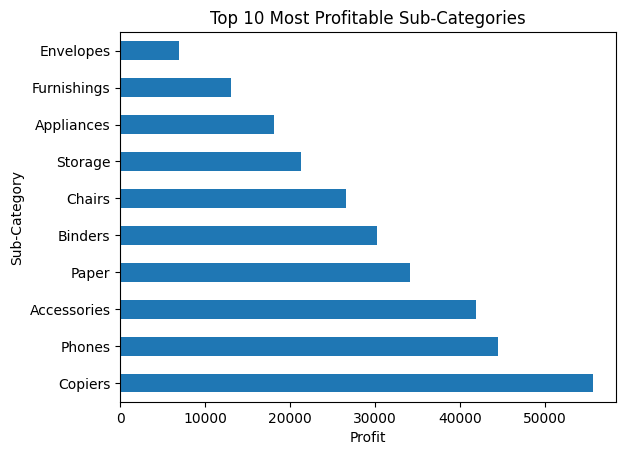

In [ ]:
subcat_profit = (df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False).head(10))

subcat_profit.plot(kind="barh")
plt.title("Top 10 Most Profitable Sub-Categories")
plt.xlabel("Profit")
plt.show()

In [ ]:
region = df.groupby("Region")[["Sales", "Profit"]].sum()
region

,Sales,Profit
Region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


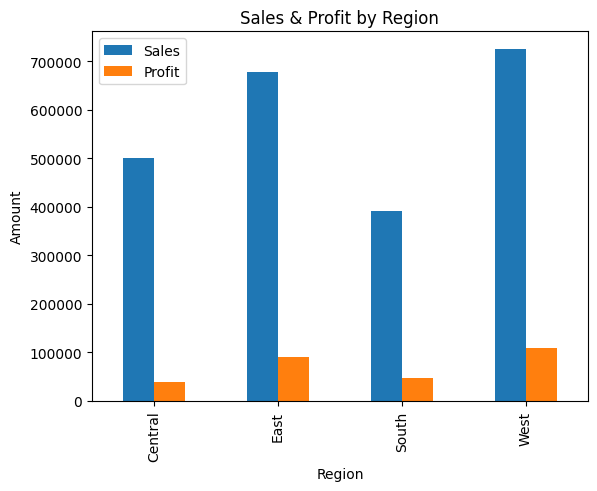

In [ ]:
region.plot(kind="bar")
plt.title("Sales & Profit by Region")
plt.ylabel("Amount")
plt.show()

In [ ]:
segment = df.groupby("Segment")[["Sales", "Profit"]].sum()
segment

,Sales,Profit
Segment,,
Consumer,1.161401e+06,134119.2092
Corporate,7.061464e+05,91979.1340
Home Office,4.296531e+05,60298.6785


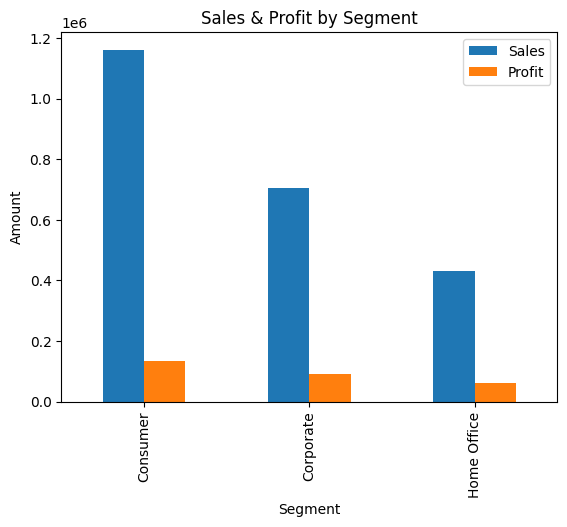

In [ ]:
segment.plot(kind="bar")
plt.title("Sales & Profit by Segment")
plt.ylabel("Amount")
plt.show()

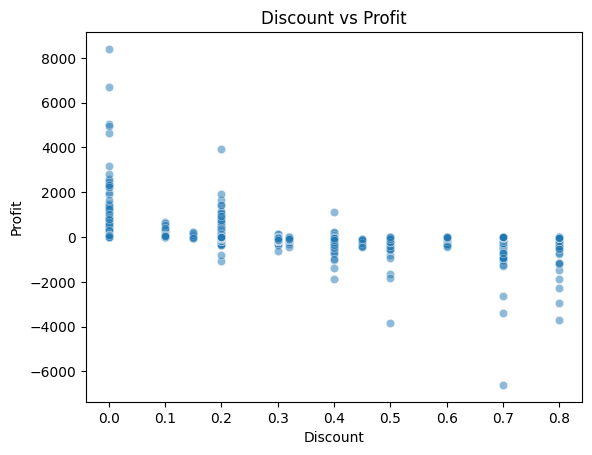

In [ ]:
sns.scatterplot(x="Discount", y="Profit", data=df, alpha=0.5)
plt.title("Discount vs Profit")
plt.show()

In [ ]:
top_sales_products = (df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10))

top_sales_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [ ]:
top_loss_products = (df.groupby("Product Name")["Profit"].sum().sort_values().head(10))
top_loss_products

,Profit
Product Name,
Cubify CubeX 3D Printer Double Head Print,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.1156
Bush Advantage Collection Racetrack Conference Table,-1934.3976
GBC DocuBind P400 Electric Binding System,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,-1299.1836
Balt Solid Wood Round Tables,-1201.0581


In [1]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [2]:
!git config --global user.name "DimasWijaya28"

In [3]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	drive/
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)


In [4]:
!git add .

error: open("drive/MyDrive/19411029_Imelda Tutuarima_SI_Proposal Skripsi (2) (1).gdoc"): Operation not supported
error: unable to index file 'drive/MyDrive/19411029_Imelda Tutuarima_SI_Proposal Skripsi (2) (1).gdoc'
fatal: adding files failed


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!git add .

error: open("drive/MyDrive/19411029_Imelda Tutuarima_SI_Proposal Skripsi (2) (1).gdoc"): Operation not supported
error: unable to index file 'drive/MyDrive/19411029_Imelda Tutuarima_SI_Proposal Skripsi (2) (1).gdoc'
fatal: adding files failed


In [7]:
%cd /content/drive/MyDrive/Portofolio/Superstore

/content/drive/MyDrive/Portofolio/Superstore


In [8]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Portofolio/Superstore/.git/


In [9]:
!git config --global user.name "DimasWijaya28"